In [7]:
import numpy as np
import pandas as pd
import sys
sys.path.append('../pyJive/')

from utils import proputils as pu
import main
from names import GlobNames as gn
from names import ParamNames as pn

%matplotlib widget


In [8]:
import numpy as np

# File path
file_path = '/mnt/data/bridge_original.geom'

# Step 1: Parse the file to extract nodes and elements
def parse_truss_file(file_path):
    nodes = {}
    elements = []
    
    with open(file_path, 'r') as file:
        lines = file.readlines()
        
    # Flag to distinguish between nodes and elements
    parsing_nodes = True
    
    for line in lines:
        parts = line.split()
        if not parts:
            continue
        
        # Switch parsing mode when encountering an empty line
        if len(parts) == 3:
            # Node format: node_id x y
            node_id = int(parts[0])
            x, y = float(parts[1]), float(parts[2])
            nodes[node_id] = (x, y)
            
        elif len(parts) == 4:
            # Element format: element_id node1 node2 area
            element_id = int(parts[0])
            node1, node2 = int(parts[0]), int(parts[1])
            area_idx = int(parts[3])
            elements.append((node1, node2, area_idx))
    
    return nodes, elements


def calculate_total_mass(nodes, elements, rho, area):
    total_volume = 0.0
    
    for element in elements:
        node1, node2, area_idx = element
        x1, y1 = nodes[node1]
        x2, y2 = nodes[node2]

        # Calculate the length of the element
        length = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)

        # Volume = length * area
        volume = length * area[area_idx]
        total_volume += volume
        total_mass = total_volume * rho
    
    return total_mass


In [9]:
def update_geom_file(geom_path, y_coordinate, update_lines, output_path=None):
    """
    Updates the y-coordinates of upper nodes in the .geom file.
    Args:
        geom_path (str): Path to the existing .geom file.
        y_coordinates (list): New y-coordinates for the upper nodes.
        output_path (str): Path to save the modified .geom file (optional).
    Returns:
        None
    """
    output_path = output_path or geom_path  # Overwrite if no output path provided

    # Read the .geom file
    with open(geom_path, 'r') as file:
        lines = file.readlines()

    # Locate and modify the section with upper node coordinates
    for i in range(len(lines)):
        if i in update_lines:
            parts = lines[i].split()
            parts[-1] = str(y_coordinate)  # Modify the last value
            lines[i] = ' '.join(parts) + '\n'        


    # Write back the updated file
    with open(output_path, 'w') as file:
        file.writelines(lines)

Initializing module chain...
[<modules.initmodule.InitModule object at 0x0000026473D40760>, <modules.modeshapemodule.ModeShapeModule object at 0x0000026473D408B0>, <modules.frameviewmodule.FrameViewModule object at 0x0000026473D40AC0>]
InitModule: Creating DofSpace...
InitModule: Reading geo mesh file bridge.geom ...
InitModule: Creating node groups...
InitModule: Created group bl with nodes [0]
InitModule: Created group br with nodes [19]
InitModule: Created group bm with nodes [9]
InitModule: Created group bottom with nodes [ 0  1  3  5  7  9 11 13 15 17 19]
InitModule: Creating model...
Creating Line2Shape...
mass  using all doftypes by default:  dict_keys(['dx', 'dy'])
Running chain...
ModeShapeModule: running eigenvalue problem...
ModeShapeModule: smallest natural frequency  7.8598e+01 rad / s


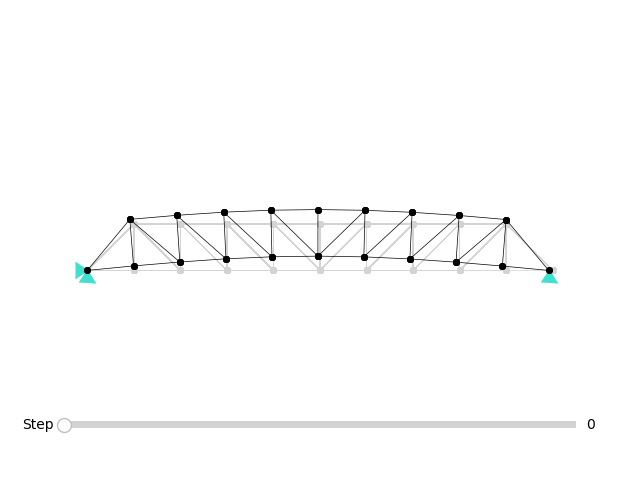

End of execution


(32.090865786510165, array([12.50922552, 34.22636165, 44.62344323]))

In [11]:
def fem_solver(x):
    # Update y-coordinates in .geom file
    update_lines = [3, 5, 7 ,9, 11, 13, 15, 17, 19]
    update_geom_file('bridge.geom', x, update_lines, output_path=None)
    
    # Load properties
    props = pu.parse_file('bridge_frequency.pro')
    
    # Update cross-section area
    # props['model']['truss']['area'] = 

    # Run FEM simulation
    globdat = main.jive(props)

    # Extract mass  
    mass_nodes = props['model']['mass']['nodeGroup']
    n_bottom_nodes = len(globdat[gn.NGROUPS][mass_nodes])
    point_mass = float(props['model']['mass']['mass'])
    weight = 0.5 * np.sum(globdat[pn.MATRIX2]) - n_bottom_nodes * point_mass
    
    # Extract natural frequencies
    frequencies = globdat[gn.EIGENFREQS][0:3] / (2 * np.pi)  # Hz
    
    return weight, frequencies

fem_solver(1)

In [6]:
# mass check
top = 8
bottom = 10
vert = 9
diag = 10
h = 1
l = top + bottom + h * vert + (1 + h*h)**0.5 * diag
area = 1e-4
rho = 7800
mass = l * area * rho
mass

32.09086578651014